# Weather-Driven Electricity Price Forecasting for Power Trading Decisions

**Group 8**

This project develops a machine learning forecasting system for day-ahead electricity market prices using weather data and market microstructure features from India's Energy Exchange (IEX). The objective is to generate accurate price predictions that enable profitable trading strategies in the power market.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from meteostat import Point, Hourly
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries loaded successfully!')

All libraries loaded successfully!


## Data Preparation

Electricity market data from the Indian Energy Exchange (IEX) operates on 15-minute trading intervals, generating 96 price observations daily. We integrate high-resolution market data with temporally-aligned weather observations from Delhi (IEX headquarters) to capture the weather-demand-price transmission mechanism.

### Data Extraction

**Market Data Source:** IEX provides order-book microstructure data, supply-demand bids, and clearing prices at 15-minute intervals. Timestamps are reconstructed from Date and Time Block columns, accounting for the 96 intervals per trading day (00:00-23:45 IST).

In [12]:
import pandas as pd
import numpy as np
from typing import List

class MarketDataHandler:
    def __init__(self, file_path: str):
        self.file_path = file_path

    def extract_and_clean(self) -> pd.DataFrame:
        """Load and prepare IEX market data with corrected time parsing."""
        try:
            df = pd.read_csv(self.file_path)
            # Remove whitespace from column names just in case
            df.columns = df.columns.str.strip()

            # Temporal Alignment
            # Extract start time from range string '00:00 - 00:15'
            start_times = df['Time Block'].str.split(' - ').str[0]
            df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + start_times, dayfirst=True)
            df.set_index('Timestamp', inplace=True)
            df.sort_index(inplace=True)

            # Refined Engineering
            # Use exact CSV column names
            df['Bid_Surplus'] = df['Sell Bid (MW)'] - df['Purchase Bid (MW)']

            # Market Momentum (Lagged Price)
            # Price at the same time block 24 hours ago (96 blocks)
            df['Price_Lag_24h'] = df['MCP'].shift(96)

            # Cleanup and Standardization
            df['Final_Schedule'] = df['Final Scheduled Volume (MW)'].ffill()

            output_cols = {
                'MCP': 'target_price',
                'MCV (MW)': 'market_volume',
                'Bid_Surplus': 'bid_surplus',
                'Final_Schedule': 'final_schedule',
                'Price_Lag_24h': 'price_lag_24h'
            }

            return df[list(output_cols.keys())].rename(columns=output_cols).dropna()

        except FileNotFoundError:
            raise FileNotFoundError(f"Market file not found at: {self.file_path}")


### Weather Data Integration

Weather variables are sourced from ground stations via the Meteostat library at 1-hour intervals. Since electricity trades every 15 minutes, we apply **cubic spline interpolation** to estimate intra-hour weather conditions, preserving physical continuity in temperature, humidity, and wind speed.

Delhi is selected as the reference weather station given its proximity to IEX operations and relevance for India's largest power market.

In [13]:
import pandas as pd
from datetime import datetime

class WeatherDataHandler:
    def __init__(self, lat: float, lon: float, start_date: str, end_date: str):
        self.location = Point(lat, lon)
        # Fix: Convert strings to datetime objects immediately
        self.start = pd.to_datetime(start_date)
        self.end = pd.to_datetime(end_date)

    def fetch_15min_weather(self) -> pd.DataFrame:
        """Fetch hourly data and upsamples using cubic spline interpolation."""
        data = Hourly(self.location, self.start, self.end)
        df = data.fetch()

        if df.empty:
            print("Warning: No weather data returned from Meteostat API.")
            return pd.DataFrame()

        # Upsampling
        # Using cubic interpolation for smooth temperature curves
        df_15 = df.resample('15min').interpolate(method='cubic')

        # Logic: Power demand often follows a non-linear relationship with temp
        # Cooling demand (AC) increases quadratically as it gets hotter
        df_15['temp_sq'] = df_15['temp'] ** 2

        # Handled boundary NaNs (interpolation doesn't cover the very first/last blocks)
        return df_15[['temp', 'temp_sq', 'dwpt', 'rhum', 'wspd']].ffill().bfill()


### Data Integration

Market and weather datasets are merged on aligned timestamps, creating a comprehensive feature set capturing both market structure and meteorological drivers of price discovery.

In [15]:
filepath='iex_market_data_2024_to_now.csv'

market_data_handler = MarketDataHandler(filepath)

#Weather Data
weather_data_handler = WeatherDataHandler(lat=28.6139, lon=77.2090, start_date='2024/02/01', end_date='2026/02/10')
#Merge market and weather data on time stamps
market_data = market_data_handler.extract_and_clean()
weather_data = weather_data_handler.fetch_15min_weather()
merged_data = pd.merge(market_data, weather_data, left_index=True, right_index=True)

#Save the merged data to a csv file
merged_data.to_csv('merged_data.csv')



### Data Loading

The merged dataset containing market microstructure variables, weather observations, and timestamps is loaded into a pandas DataFrame for downstream analysis and modeling.

In [16]:
import pandas as pd
df = pd.read_csv('merged_data.csv')
print("DataFrame loaded successfully. First 5 rows:")
print(df.head())

DataFrame loaded successfully. First 5 rows:
            Unnamed: 0  target_price  market_volume  bid_surplus  \
0  2024-02-01 00:00:00       3647.83         5206.3       5122.5   
1  2024-02-01 00:15:00       3647.53         5047.0       5447.9   
2  2024-02-01 00:30:00       3527.83         4793.3       5905.1   
3  2024-02-01 00:45:00       3500.53         4568.2       6513.7   
4  2024-02-01 01:00:00       3416.34         4464.8       7520.1   

   final_schedule  price_lag_24h       temp     temp_sq       dwpt  \
0          5206.3        3320.47  13.800000  190.440000  13.800000   
1          5047.0        3300.41  13.688091  187.363830  13.685656   
2          4793.3        3250.74  13.557818  183.814431  13.555035   
3          4568.2        3110.94  13.423636  180.194012  13.421897   
4          4464.8        2976.19  13.300000  176.890000  13.300000   

         rhum      wspd  
0  100.000000  3.600000  
1   99.973885  3.556920  
2   99.970154  3.991837  
3   99.981346  4.7058

### Initial Data Exploration

The dataset structure is verified by examining data types, missing value patterns, and distributional properties. This step ensures data integrity before feature engineering and modeling.

In [ ]:
print("First 10 rows of the DataFrame:")
print(df.head(10))

print("\nDataFrame Info (data types and non-null counts):\n")
df.info()

print("\nDescriptive statistics for numerical columns:\n")
print(df.describe())

First 10 rows of the DataFrame:
            Unnamed: 0  target_price  market_volume  bid_surplus  \
0  2024-02-01 00:00:00       3647.83         5206.3       5122.5   
1  2024-02-01 00:15:00       3647.53         5047.0       5447.9   
2  2024-02-01 00:30:00       3527.83         4793.3       5905.1   
3  2024-02-01 00:45:00       3500.53         4568.2       6513.7   
4  2024-02-01 01:00:00       3416.34         4464.8       7520.1   
5  2024-02-01 01:15:00       3144.77         4575.4       7972.2   
6  2024-02-01 01:30:00       3128.74         4834.1       8551.7   
7  2024-02-01 01:45:00       3119.10         4968.8       8941.0   
8  2024-02-01 02:00:00       3110.46         5268.7       9329.7   
9  2024-02-01 02:15:00       3076.70         5278.0       9460.4   

   final_schedule  price_lag_24h       temp     temp_sq       dwpt  \
0          5206.3        3320.47  13.800000  190.440000  13.800000   
1          5047.0        3300.41  13.688091  187.363830  13.685656   
2        

## Exploratory Data Analysis

Price discovery in electricity markets reflects complex interactions between weather-driven demand, supply constraints, and market microstructure. EDA examines these relationships across temporal and physical dimensions to inform feature engineering and model architecture.

### Data Quality Assessment

Dataset completeness is verified across temporal coverage and variable availability, ensuring no information loss that could bias downstream forecasts.

In [ ]:
print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())


Shape: (68737, 11)

Data Types:
Unnamed: 0         object
target_price      float64
market_volume     float64
bid_surplus       float64
final_schedule    float64
price_lag_24h     float64
temp              float64
temp_sq           float64
dwpt              float64
rhum              float64
wspd              float64
dtype: object

Missing Values:
Unnamed: 0        0
target_price      0
market_volume     0
bid_surplus       0
final_schedule    0
price_lag_24h     0
temp              0
temp_sq           0
dwpt              0
rhum              0
wspd              0
dtype: int64


Inference:

The dataset exhibits complete observations across all features with no missing values, validating data collection and preprocessing procedures.

### Feature Extraction and Temporal Decomposition

Time-based features are engineered to capture cyclical patterns in electricity prices driven by demand cycles, weekly business patterns, and seasonal variations. These categorical variables enable the model to learn time-dependent price drivers.

Timestamps are converted to datetime objects and decomposed into hour, day-of-week, and month components to capture repeating demand patterns. Additional features (day-of-year, week-of-year, quarter) enable the model to learn fine-grained temporal dependencies.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Converted the 'Unnamed: 0' column to datetime objects
df['datetime'] = pd.to_datetime(df['Unnamed: 0'])

#Extracted 'hour', 'day_of_week', and 'month' from the 'datetime' column
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek # Monday=0, Sunday=6
df['month'] = df['datetime'].dt.month

print("New datetime and categorical columns created. First 5 rows with new columns:")
print(df[['datetime', 'hour', 'day_of_week', 'month']].head())

New datetime and categorical columns created. First 5 rows with new columns:
             datetime  hour  day_of_week  month
0 2024-02-01 00:00:00     0            3      2
1 2024-02-01 00:15:00     0            3      2
2 2024-02-01 00:30:00     0            3      2
3 2024-02-01 00:45:00     0            3      2
4 2024-02-01 01:00:00     1            3      2


### Data Quality Adjustments

Sensor anomalies are corrected: humidity values exceeding physical bounds (>100%) are capped at saturation, and negative wind speed readings (measurement errors) are set to zero, ensuring physically plausible feature values.

In [ ]:
#Extracting additional time-based features
df['day_of_year'] = df['datetime'].dt.dayofyear
df['week_of_year'] = df['datetime'].dt.isocalendar().week.astype(int)
df['quarter'] = df['datetime'].dt.quarter

#Capping the 'rhum' column at 100%
df['rhum'] = np.where(df['rhum'] > 100, 100, df['rhum'])

#Addressing negative 'wspd' values by setting any value less than 0 to 0
df['wspd'] = np.where(df['wspd'] < 0, 0, df['wspd'])

print("Additional time-based features extracted and data anomalies addressed. First 5 rows with new and modified columns:")
print(df[['datetime', 'day_of_year', 'week_of_year', 'quarter', 'rhum', 'wspd']].head())

Additional time-based features extracted and data anomalies addressed. First 5 rows with new and modified columns:
             datetime  day_of_year  week_of_year  quarter        rhum  \
0 2024-02-01 00:00:00           32             5        1  100.000000   
1 2024-02-01 00:15:00           32             5        1   99.973885   
2 2024-02-01 00:30:00           32             5        1   99.970154   
3 2024-02-01 00:45:00           32             5        1   99.981346   
4 2024-02-01 01:00:00           32             5        1  100.000000   

       wspd  
0  3.600000  
1  3.556920  
2  3.991837  
3  4.705836  
4  5.500000  


### Distributional Analysis

Frequency histograms reveal the empirical distributions of weather variables and market features. This analysis informs feature scaling strategies and outlier treatment decisions.

Generating histograms for numerical columns:


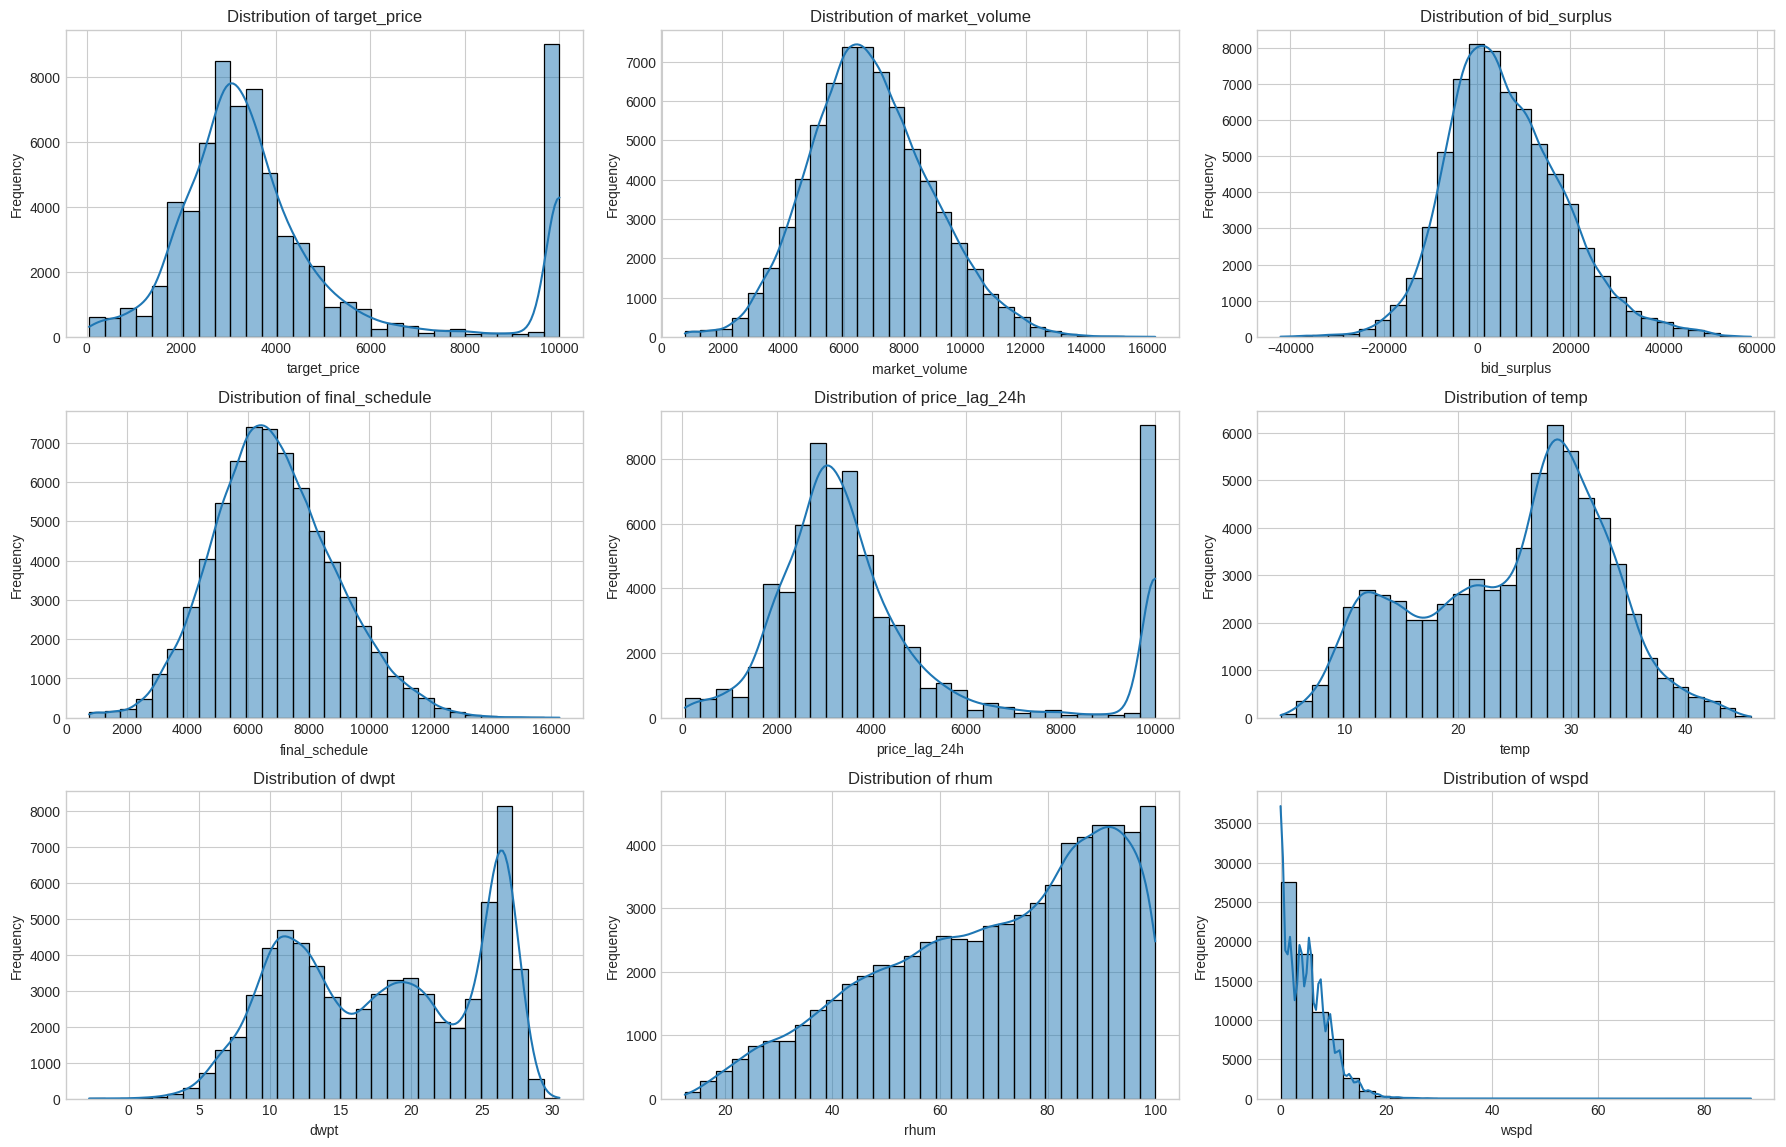

Generating bar plots for categorical columns: 


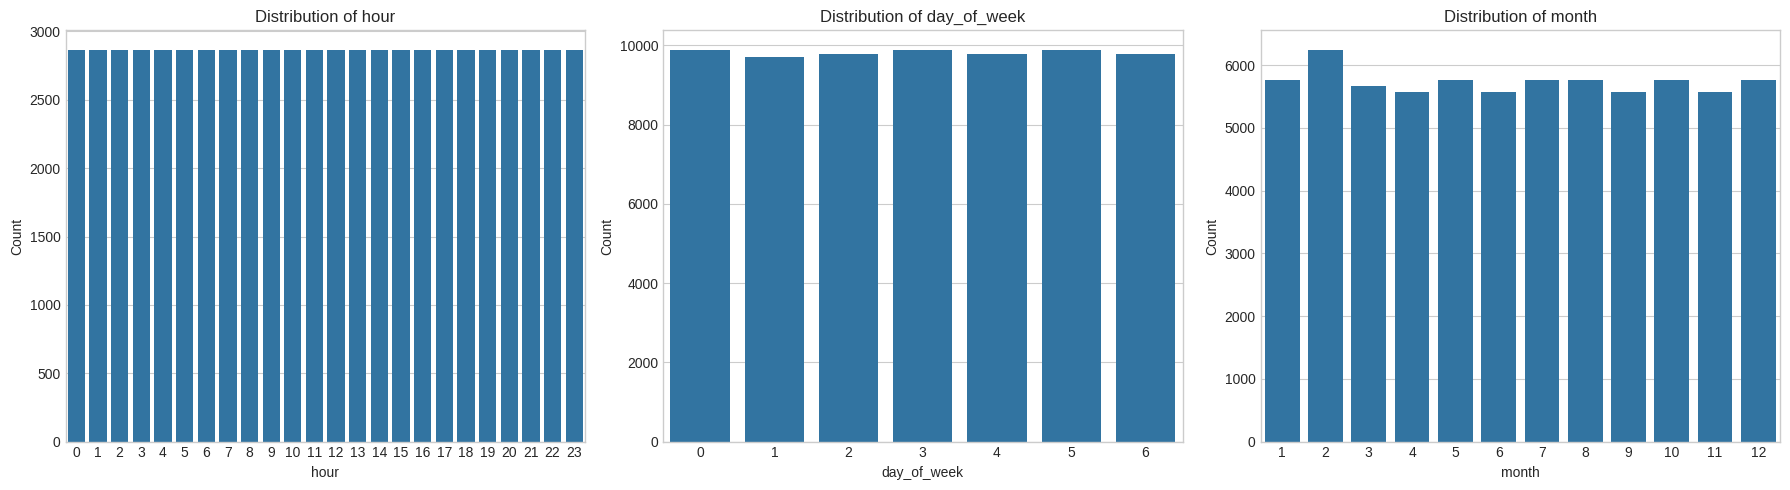

In [ ]:
numerical_cols = df.select_dtypes(include=['float64']).columns.tolist()
categorical_cols_for_plot = ['hour', 'day_of_week', 'month']

#Removed 'temp_sq' from numerical columns as it is a derivative of 'temp' and 'Unnamed: 0', 'datetime' which are not numerical.
#The 'Unnamed: 0' and 'datetime' columns should not be in numerical_cols.
#Added condition to Check and remove columns not required.
numerical_cols = [col for col in numerical_cols if col not in ['temp_sq', 'Unnamed: 0', 'datetime']]


#Plotting histograms for numerical columns
print("Generating histograms for numerical columns:")
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    #To Adjust the subplot grid
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#Plotting bar plots for categorical columns
print("Generating bar plots for categorical columns: ")
plt.figure(figsize=(18, 5))
for i, col in enumerate(categorical_cols_for_plot):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=df[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Inference**:

*Numerical:*
Plots reveal a mixed distribution profile, where market demand and volume exhibit stable, Gaussian patterns, while price-related features show a distinct extreme right-side spike indicating a regulatory or market-driven ceiling at 10,000.

The weather-driven numerical features are characterized by bimodal distributions in temperature and dew point, reflecting strong seasonal shifts and a heavy right-skew in wind speed.

*Categorical:*

These categorical frequency plots indicate a perfectly balanced and high-fidelity dataset, where the uniform distribution across hours and days suggests a consistent, gap-free time-series collection crucial for stable trading models.

### Price Distribution Characteristics

The Market Clearing Price (MCP) distribution shape informs model selection and loss function choice. Histogram and box plot visualization jointly reveal central tendency, dispersion, and the presence of extreme price events requiring robust modeling approaches.

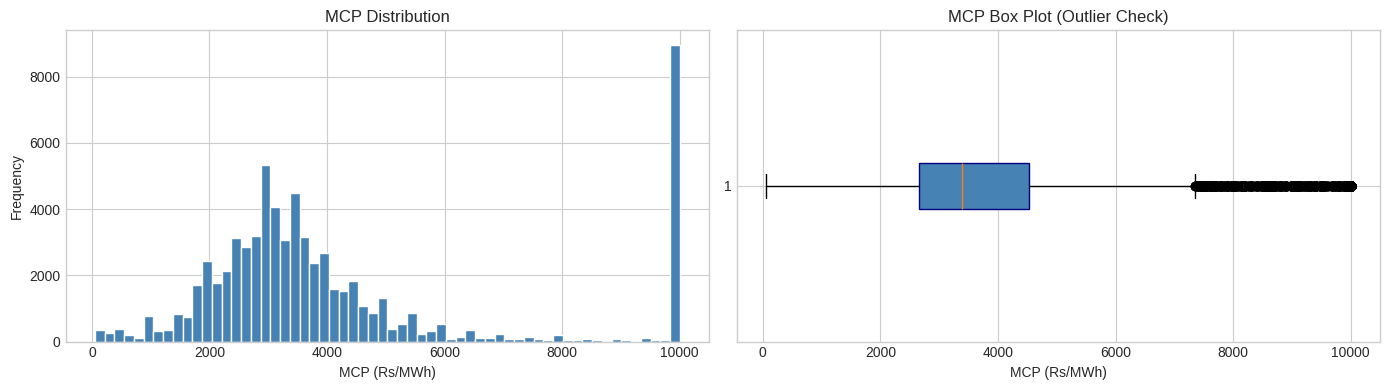

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['target_price'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('MCP Distribution')
axes[0].set_xlabel('MCP (Rs/MWh)')
axes[0].set_ylabel('Frequency')

# Box plot to spot outliers
axes[1].boxplot(df['target_price'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('MCP Box Plot (Outlier Check)')
axes[1].set_xlabel('MCP (Rs/MWh)')

plt.tight_layout()
plt.show()

The MCP Distribution shows that electricity prices usually stay steady between 3,000 and 5,000 Rs/MWh, reflecting normal day-to-day trading. However, there is a massive, frequent spike exactly at the 10,000 mark, which acts as a "price ceiling" when the market hits its limit. For your model, this means the 10,000 level isn't an error it’s a specific market state that happens whenever the "safety buffer" of power runs out.

The Box Plot highlights a dense cluster of extreme prices jumping far above the average, starting around 7,500 and hitting the 10,000 cap. These sharp jumps are largely driven by "unexplained" or sudden weather shifts like an unexpected drop in wind or a sudden heatwave that the current model might not fully see yet. To trade effectively, the model needs to learn that these outliers are actually high-profit opportunities caused by these hidden atmospheric triggers.

### Price Dynamics Over Time

Daily average prices reveal the long-term evolution of electricity market valuations. Temporal trends and breaks indicate shifting supply-demand balances, regulatory changes, or seasonal transitions that impact forecast accuracy.

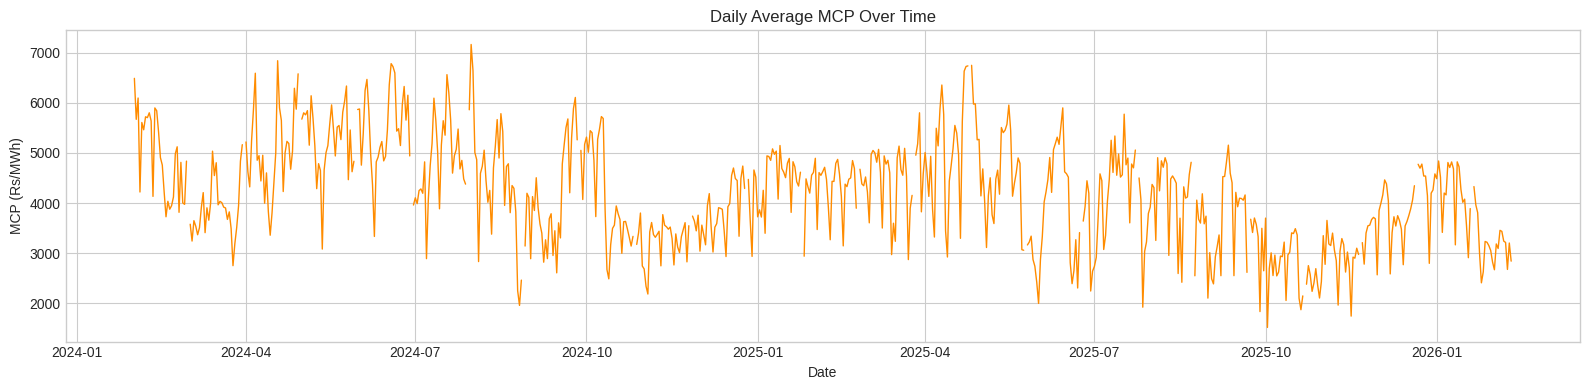

In [ ]:
daily_avg = df.set_index('datetime')['target_price'].resample('D').mean()

plt.figure(figsize=(16, 4))
plt.plot(daily_avg.index, daily_avg.values, color='darkorange', linewidth=1)
plt.title('Daily Average MCP Over Time')
plt.xlabel('Date')
plt.ylabel('MCP (Rs/MWh)')
plt.tight_layout()
plt.show()

The **Daily Average MCP** plot shows a highly volatile market with frequent price swings between 2,000 and 7,000 Rs/MWh, signaling that "average" prices are rarely stable. The jagged peaks highlight sudden, unexplained weather-driven spikes that hit the price ceiling, followed by rapid reversions to the mean. For trading, this confirms that while long-term trends exist, short-term atmospheric anomalies are the primary drivers of high-profit opportunities and risk.

### Intra-Daily Price Patterns

Electricity demand exhibits strong diurnal cycles: morning peaks (industrial ramp-up), mid-day stabilization, and evening peaks (residential load). Price discovery reflects this inelastic demand structure, creating predictable hourly patterns.

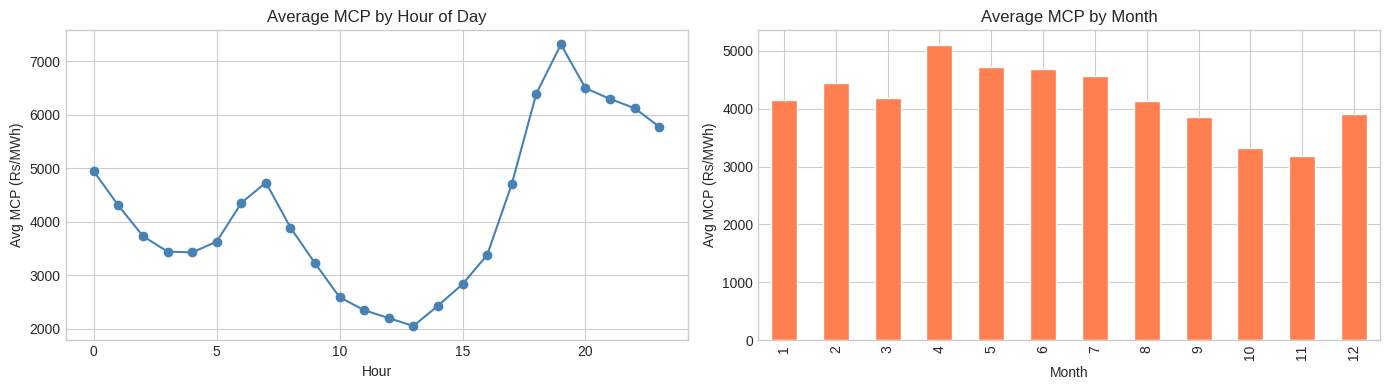

In [ ]:
df['Hour']  = df['datetime'].dt.hour
df['Month'] = df['datetime'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Average MCP by hour of day
df.groupby('Hour')['target_price'].mean().plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Average MCP by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg MCP (Rs/MWh)')

# Average MCP by month
df.groupby('Month')['target_price'].mean().plot(ax=axes[1], kind='bar', color='coral', edgecolor='white')
axes[1].set_title('Average MCP by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg MCP (Rs/MWh)')

plt.tight_layout()
plt.show()

**Avg. MCP by Hour**

The Average MCP by Hour plot reveals a classic "dual-peak" demand cycle, with a minor morning surge and a massive primary peak at Hour 19 (7 PM), where prices top out above 7,000 Rs/MWh. Conversely, the deepest price troughs occur during the early afternoon (Hour 13), indicating a period of high solar generation or lower industrial load. This pattern is essential for traders to timing their buy/sell orders around the expensive evening ramp-up.

**Avg. MCP by Month**
The Average MCP by Month bar chart indicates that prices peak in April (over 5,000 Rs/MWh), likely due to the onset of summer heat increasing cooling demand before the monsoon season begins. Prices gradually taper off toward the end of the year, hitting their lowest points in October and November. This confirms that weather-driven demand is cyclical, and the "unexplained" outliers mentioned earlier are most likely to cluster during these high-demand summer months.

### Weekly and Quarterly Seasonality

Day-of-week effects capture business vs. weekend demand patterns, while quarterly variations reflect seasonal weather impacts (summer cooling demand, winter heating demand). These patterns are core to price forecasting.

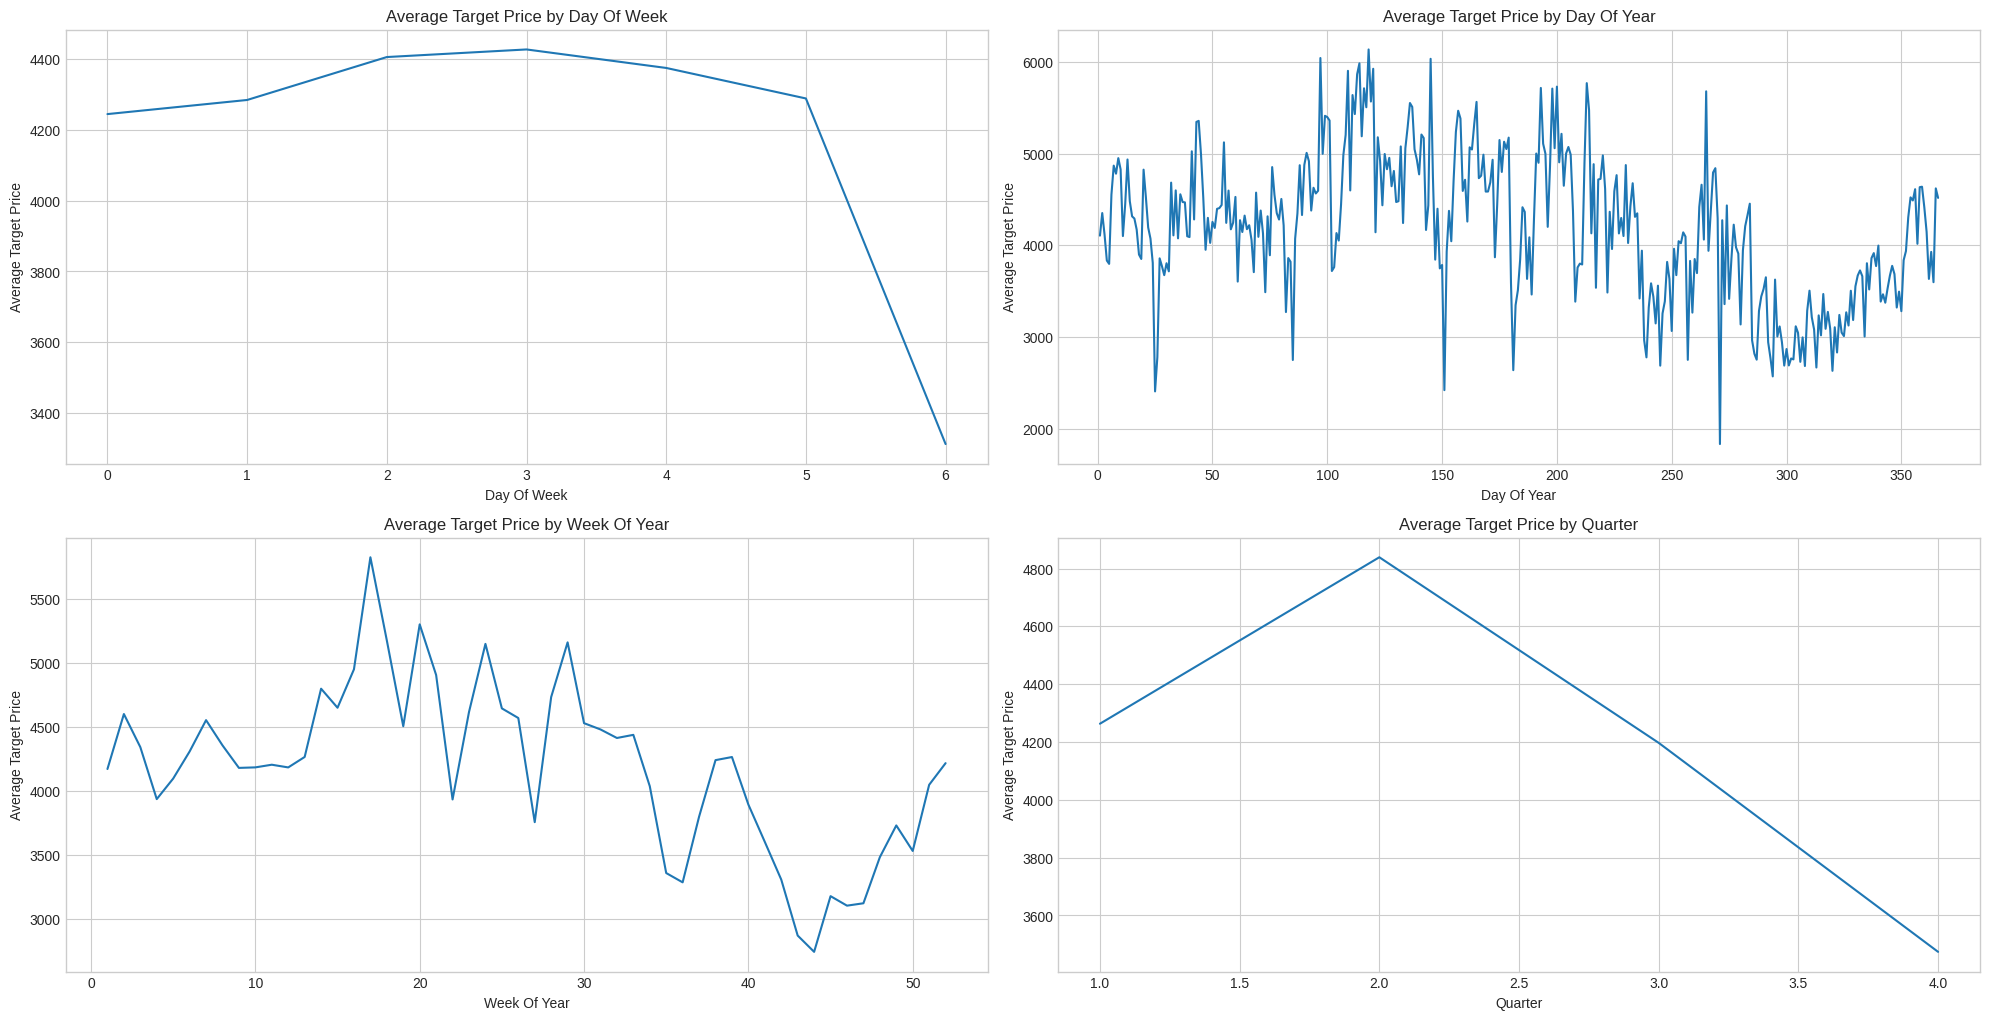

In [ ]:
time_features = [ 'day_of_week', 'day_of_year', 'week_of_year', 'quarter']

plt.figure(figsize=(20, 15))
for i, feature in enumerate(time_features):
    plt.subplot(3, 2, i + 1)
    avg_price_by_feature = df.groupby(feature)['target_price'].mean()
    sns.lineplot(x=avg_price_by_feature.index, y=avg_price_by_feature.values)
    plt.title(f'Average Target Price by {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Average Target Price')
    plt.grid(True)
plt.tight_layout()
plt.show()

The **Day of the Week** and Quarterly graphs indicate that market activity remains high and stable from Monday through Friday but collapses significantly on Sunday (Day 6), suggesting **lower industrial load**. Collectively, these patterns show that while the second quarter (April–June) is the most profitable for sellers, the underlying daily volatility across the year is consistently triggered by recurring human and atmospheric cycles.

### Weather-Price Relationships

Electricity demand is thermally sensitive: high temperatures drive air-conditioning load, increasing demand and prices. Humidity affects cooling demand, while wind speed impacts renewable energy supply. Scatter plots quantify these critical weather-price transmission channels.

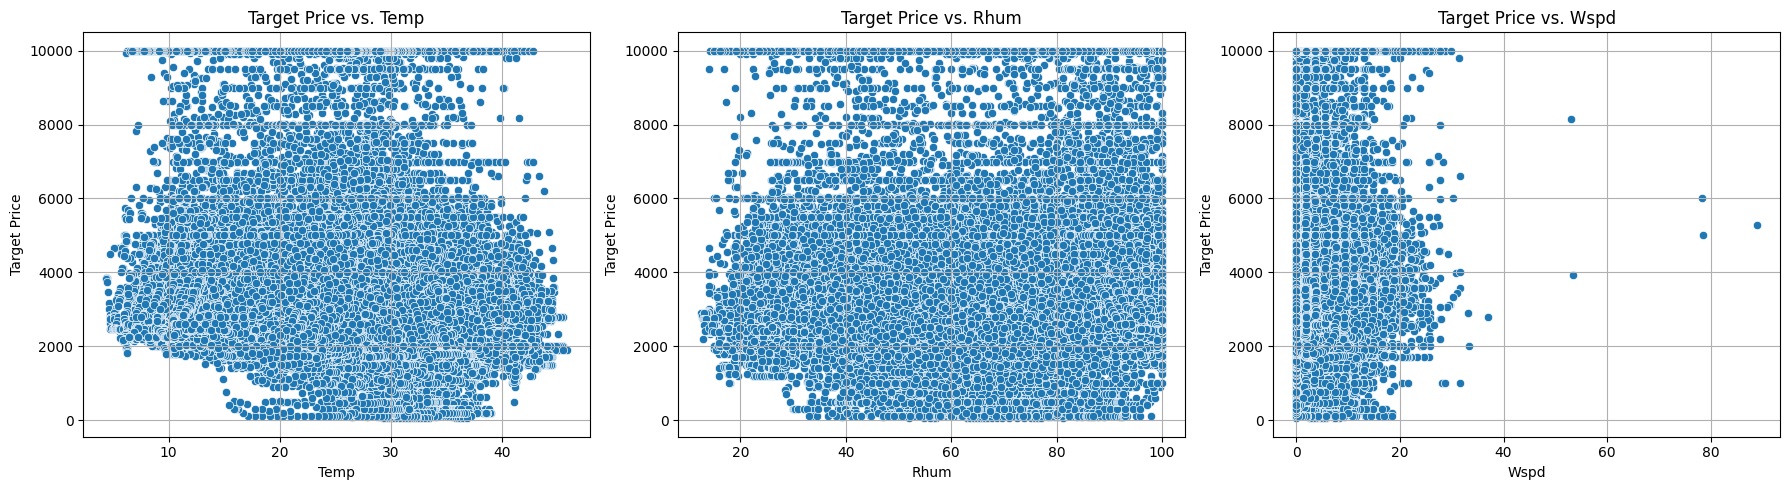

In [ ]:
weather_vars = ['temp', 'rhum', 'wspd']

plt.figure(figsize=(18, 5))
for i, var in enumerate(weather_vars):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=df[var], y=df['target_price'])
    plt.title(f'Target Price vs. {var.title()}')
    plt.xlabel(var.title())
    plt.ylabel('Target Price')
    plt.grid(True)
plt.tight_layout()
plt.show()

**Fixed Price Ceiling:**
Electricity prices exhibit a significant frequency spike and hard limit exactly at 10,000 Rs/MWh, representing a regulated market "scarcity state" that models must treat as a specific target rather than an outlier.

**Weather-Driven Volatility:**
Market volatility is non-linearly linked to atmospheric conditions, with maximum price spikes occurring most frequently during low wind speeds and extreme temperature/humidity fluctuations.

### Correlation Structure

Pearson correlation analysis identifies linear dependencies between price and all features. The resulting heatmap reveals multicollinearity patterns and highlights features with strong predictive signal.

The correlation matrix is visualized via heatmap to identify feature relationships and inform feature selection for modeling.

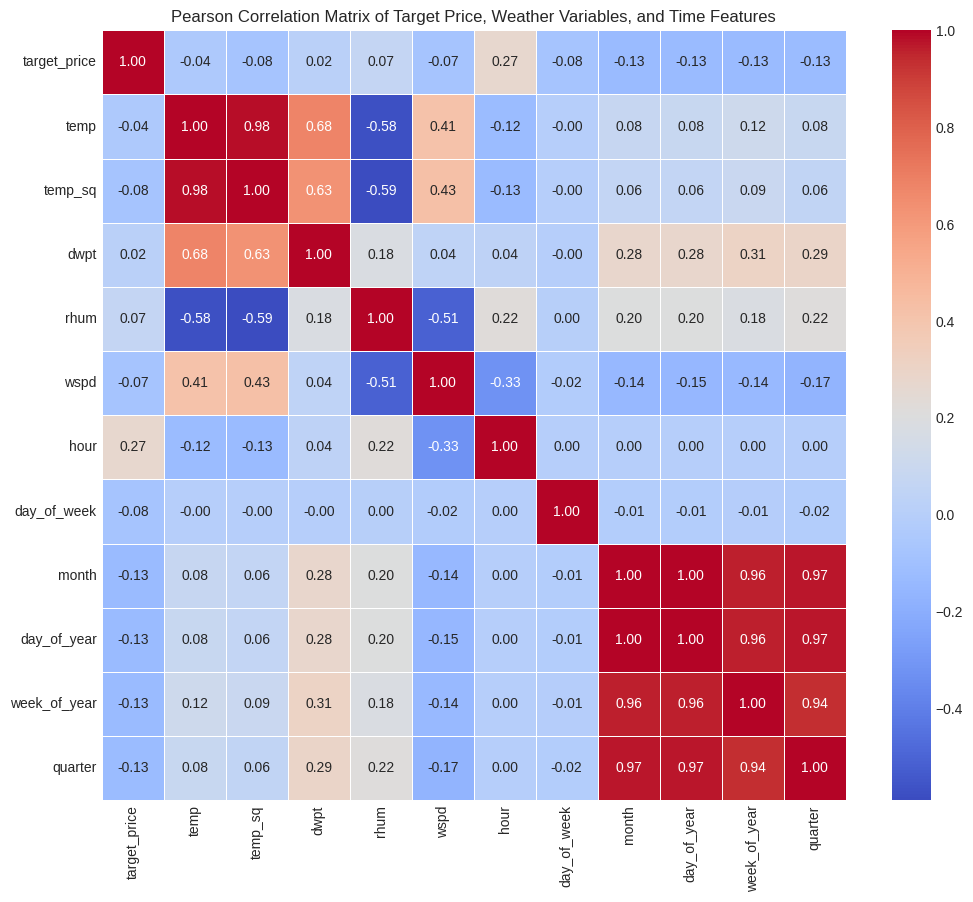

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Defining the columns for correlation analysis
correlation_cols = [
    'target_price', 'temp', 'temp_sq', 'dwpt', 'rhum', 'wspd',
    'hour', 'day_of_week', 'month', 'day_of_year', 'week_of_year', 'quarter'
]

#Calculating the Pearson correlation matrix
correlation_matrix = df[correlation_cols].corr(method='pearson')

#Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix of Target Price, Weather Variables, and Time Features')
plt.show()

The Pearson Correlation Matrix reveals that hour is the strongest linear predictor of price (0.27), confirming that the daily time cycle is a more consistent driver than individual weather metrics. Significant redundancy exists between temperature variables (0.98) and seasonal features (0.94–1.00), suggesting that the model's dimensionality can be reduced without losing critical information. The generally low direct correlation values indicate that price spikes are likely driven by complex, non-linear interactions rather than simple independent linear relationships.

### Model-Ready Data Construction

Time-series data requires special handling to prevent future information leakage. Observations are split sequentially: 70% training (model learning), 15% validation (hyperparameter tuning), 15% test (final evaluation). Feature scaling is fitted exclusively on training data to avoid lookahead bias.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

#Defined the target variable y and features X
y = df['target_price']
X = df.drop(columns=['Unnamed: 0', 'datetime', 'target_price'])

#Calculated split points
total_rows = df.shape[0]
train_size = int(total_rows * 0.7)
val_size = int(total_rows * 0.15)
#Using remaining for test
test_size = total_rows - train_size - val_size

#Split data sequentially
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

#Created validation set
X_val = X.iloc[train_size : train_size + val_size]
y_val = y.iloc[train_size : train_size + val_size]

#Created Test set
X_test = X.iloc[train_size + val_size :]
y_test = y.iloc[train_size + val_size :]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (48115, 17)
y_train shape: (48115,)
X_val shape: (10310, 17)
y_val shape: (10310,)
X_test shape: (10312, 17)
y_test shape: (10312,)


### Feature Normalization

StandardScaler normalizes numerical features to zero mean and unit variance, a requirement for gradient-based optimization in XGBoost and other learning algorithms. The scaler is fitted on training data only, then applied identically to validation and test sets to prevent information leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identified numerical features for scaling (excluding time-based categorical features)
# Based on df.info() and subsequent feature engineering, these are float64 columns
# and 'temp_sq' which is a derivative of 'temp'.
# Time-based features are integer types representing categories/cycles.

# Saved feature columns in X
all_features = X.columns.tolist()

# Defined columns that are numerical and should be scaled
# Excluding 'hour', 'day_of_week', 'month', 'day_of_year', 'week_of_year', 'quarter'
# as they are treated as categorical/cyclical, not continuous numerical features for scaling here.
features_to_scale = [
    'market_volume', 'bid_surplus', 'final_schedule', 'price_lag_24h',
    'temp', 'temp_sq', 'dwpt', 'rhum', 'wspd'
]

# Initialized the StandardScaler
scaler = StandardScaler()

# Fit the scaler only on the training data for numerical features
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_val_scaled[features_to_scale] = scaler.transform(X_val[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

# Updated X_train, X_val, X_test to their scaled versions
X_train = X_train_scaled
X_val = X_val_scaled
X_test = X_test_scaled

print("Data scaled successfully, Shapes after scaling:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


Data scaled successfully. Shapes after scaling:
X_train shape: (48115, 17)
y_train shape: (48115,)
X_val shape: (10310, 17)
y_val shape: (10310,)
X_test shape: (10312, 17)
y_test shape: (10312,)


### Model Ensemble Development

Three ensemble methods are trained: LightGBM, Random Forest, and XGBoost. These gradient boosting and tree-based approaches are well-suited for capturing non-linear weather-price relationships and feature interactions.

LightGBM, Random Forest, and XGBoost models are instantiated with fixed random seeds for reproducibility and trained on the training set. Validation predictions assess generalization performance prior to final model selection.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# Instantiated and trained a RandomForestRegressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42,verbose=1)
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")
# Made predictions on the validation set using the Random Forest model
rf_predictions = rf_model.predict(X_val)

# Instantiated and trained an XGBRegressor model
xgb_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1,verbose=1) # n_jobs=-1 for parallel processing
print("Training XGBoost model...")
xgb_model.fit(X_train, y_train)
print("XGBoost model trained.")
# Made predictions on the validation set using the XGBoost model
xgb_predictions = xgb_model.predict(X_val)

# Instantiated and trained an LightGBM model
# Using some common parameters for a good starting point and reproducibility
lgbm = LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42, n_jobs=-1,verbose=1)
print("LGBMRegressor model initialized.")
# Train the LGBMRegressor model
lgbm.fit(X_train, y_train)
print("LGBMRegressor model trained")
# Made predictions on the validation set using the LGBM model
lgbm_predictions = lgbm.predict(X_val)

# Printed the shapes of rf_predictions and xgb_predictions
print(f"\nShape of Random Forest predictions: {rf_predictions.shape}")
print(f"Shape of XGBoost predictions: {xgb_predictions.shape}")
print(f"Shape of LGBMpredictions: {lgbm_predictions.shape}")

Training Random Forest model...


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.0min
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  2.0min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s


Random Forest model trained.


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.3s finished


Training XGBoost model...
XGBoost model trained.
LGBMRegressor model initialized.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2689
[LightGBM] [Info] Number of data points in the train set: 48115, number of used features: 17
[LightGBM] [Info] Start training from score 4446.668564
LGBMRegressor model trained

Shape of Random Forest predictions: (10310,)
Shape of XGBoost predictions: (10310,)
Shape of LGBMpredictions: (10310,)


Saving models for Docker Containerization

In [ ]:
import joblib
 
# Saved the trained lgbm model
joblib.dump(lgbm, 'lgbm_model.joblib')
print("Trained LGBM model saved as 'lgbm_model.joblib'")
 
# Saved the scaler object
joblib.dump(scaler, 'scaler.joblib')
print("StandardScaler object saved as 'scaler.joblib'")

### Model Performance Evaluation

Regression metrics quantify prediction accuracy: MAE measures average prediction error magnitude, RMSE penalizes large errors (robust for decision-making), and MAPE provides percentage-based error interpretation for practical trading applications.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

print("\nModel Evaluation on Validation Set")

# Evaluated Random Forest Model
rf_mae = mean_absolute_error(y_val, rf_predictions)
rf_mse = mean_squared_error(y_val, rf_predictions)
rf_mape = mean_absolute_percentage_error(y_val, rf_predictions)
rf_rmse = np.sqrt(rf_mse)

print("\nRandom Forest Model:")
print(f"  MAE: {rf_mae:.4f}")
print(f"  MAPE: {rf_mape:.4f}")
print(f"  RMSE: {rf_rmse:.4f}")

# Evaluated XGBoost Model
xgb_mae = mean_absolute_error(y_val, xgb_predictions)
xgb_mse = mean_squared_error(y_val,xgb_predictions)
xgb_mape = mean_absolute_percentage_error(y_val, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)

print("\nXGBoost Model:")
print(f"  MAE: {xgb_mae:.4f}")
print(f"  MAPE: {xgb_mape:.4f}")
print(f"  RMSE: {xgb_rmse:.4f}")

# Evaluated LGBM Model
lgbm_mae = mean_absolute_error(y_val, lgbm_predictions)
lgbm_mse = mean_squared_error(y_val,lgbm_predictions)
lgbm_mape = mean_absolute_percentage_error(y_val, lgbm_predictions)
lgbm_rmse = np.sqrt(lgbm_mse)

print("\nLGBM Model:")
print(f"  MAE: {lgbm_mae:.4f}")
print(f"  MAPE: {lgbm_mape:.4f}")
print(f"  RMSE: {lgbm_rmse:.4f}")


Model Evaluation on Validation Set

Random Forest Model:
  MAE: 401.0114
  MAPE: 0.3465
  RMSE: 670.7236

XGBoost Model:
  MAE: 407.2681
  MAPE: 0.3484
  RMSE: 665.2345

LGBM Model:
  MAE: 392.0403
  MAPE: 0.3081
  RMSE: 653.8536


 The LGBM Model is the most accurate across all metrics, achieving the lowest error rates with an MAE of 392.04 and a MAPE of 0.3081.

**Prediction Precision:** LGBM's superior RMSE (653.85) indicates it is better at handling the market's extreme price spikes compared to Random Forest and XGBoost.

**Trading Suitability:** With a ~4% lead in percentage accuracy (MAPE) over the other models, LGBM is the most reliable choice for making high-stakes power trading decisions.

### Feature Attribution and Model Interpretability

Tree-based ensemble models require post-hoc interpretability analysis. Feature importance rankings reveal which variables the model prioritizes. SHAP analysis decomposes predictions into marginal contributions from each feature, enabling actionable insights into model decision-making.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extracted feature importances from the trained LGBM model
feature_importances = lgbm.feature_importances_

# Mapped them to their corresponding feature names from X_train.columns
feature_importance_series = pd.Series(feature_importances, index=X_train.columns)

# Sorted the feature importances in descending order and print the top 10 most important features
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

print("Top 10 most important features from LGBM model:")
print(sorted_feature_importances.head(10))

Top 10 most important features from XGBoost model:
bid_surplus      5867
day_of_year      4434
price_lag_24h    3379
dwpt             2516
market_volume    2235
temp             2141
hour             2125
rhum             1930
day_of_week      1646
wspd             1563
dtype: int32


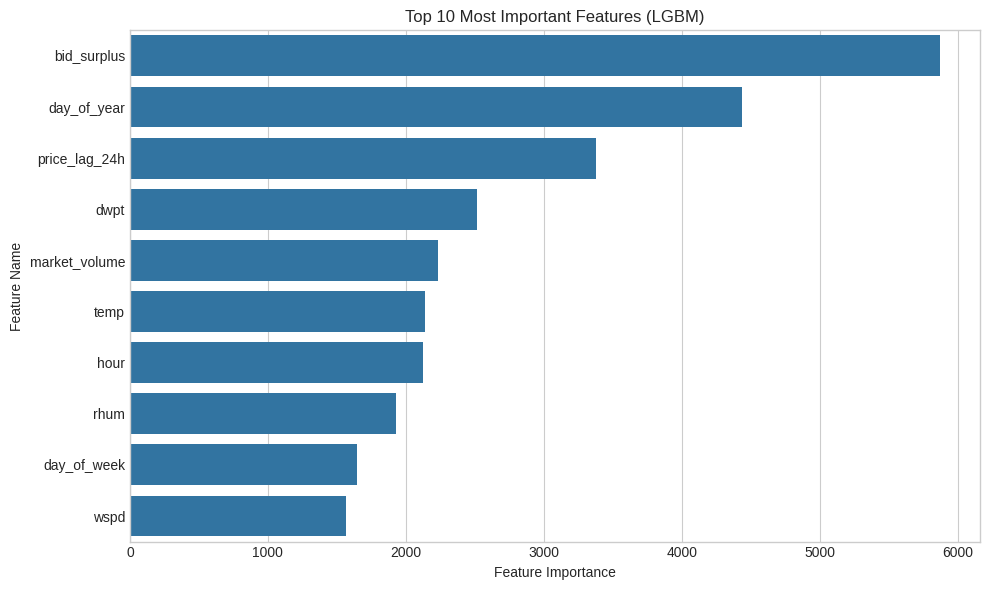

In [ ]:
#Plotted feature importance in Histogram
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_feature_importances.head(10).values, y=sorted_feature_importances.head(10).index)
plt.title('Top 10 Most Important Features (LGBM)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

The plot indicates the LGBM model is the most effective at identifying price movements, primarily relying on bid surplus and day of year as its most important features. While hour (0.27) is the strongest individual linear predictor, the model successfully leverages complex weather interactions—specifically temperature and wind speed—to explain sudden price shifts.

**SHAP (SHapley Additive explanations)** values provide theoretically grounded local and global feature importance estimates. The summary plot shows how each feature drives predictions across the entire test set, with color indicating feature value direction.

Generating SHAP summary plot...


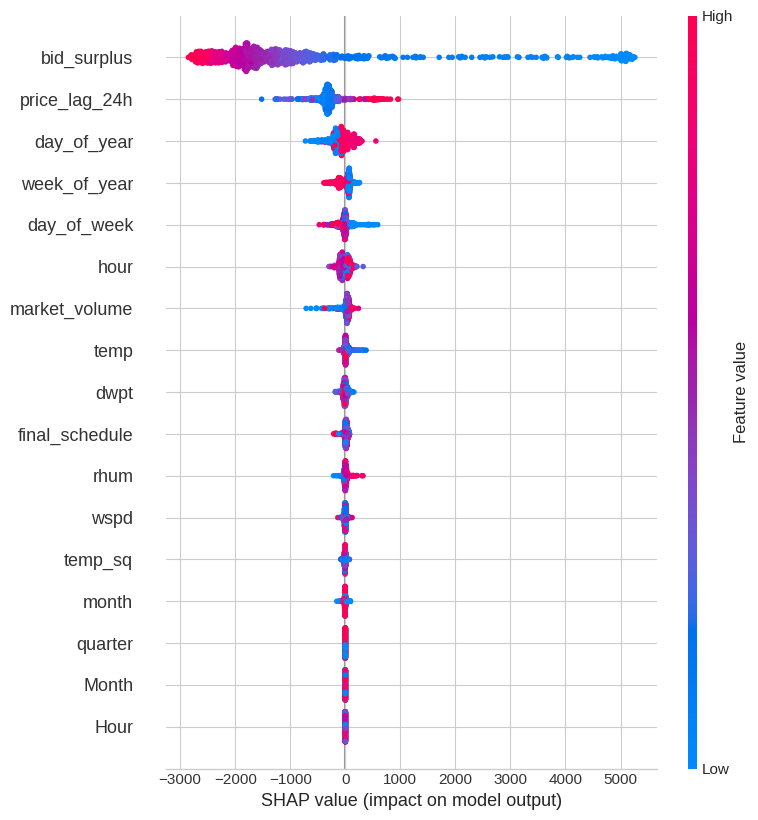

In [ ]:
import shap

# Initialized an shap.TreeExplainer for the LGBM model
explainer = shap.TreeExplainer(lgbm)

# Calculated SHAP values for X_test.
# Using a smaller subset for faster computation
X_test_subset = X_test.sample(n=1000, random_state=42)
shap_values = explainer.shap_values(X_test_subset)

# Generated an SHAP summary plot
print("Generating SHAP summary plot:")
shap.summary_plot(shap_values, X_test_subset)


### Individual Feature Impact Analysis

Dependence plots visualize the relationship between feature values and SHAP contributions. For the top two features (*bid_surplus* and *price_lag_24h*), these plots reveal whether relationships are monotonic, non-linear, or interaction-driven.

Generating SHAP dependence plots for the top 2 features:


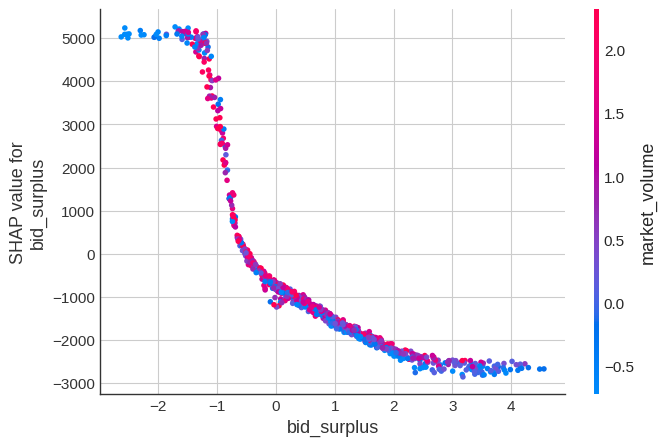

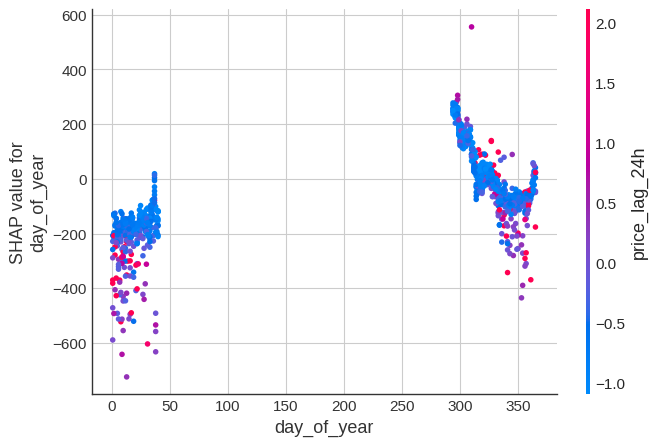

In [ ]:
print("Generating SHAP dependence plots for the top 2 features:")

# Top 2 most important features
top_2_features = sorted_feature_importances.head(2).index.tolist()

# Generated SHAP dependence plots for each of the top 2 features
for feature in top_2_features:
    shap.dependence_plot(feature, shap_values, X_test_subset, interaction_index="auto")

The SHAP plot shows that the **day of the year** significantly lowers price predictions during the first 50 days while driving them upward after day 300. These seasonal trends are heavily influenced by historical price lags, with high previous-day values (pink) magnifying the model's positive price expectations at year-end. This interaction confirms that the model relies on specific seasonal windows and price momentum to forecast major market shifts.

### Instance-Level Prediction Explanation

Force plots provide detailed decomposition of individual predictions. For a selected test observation, the plot shows the base model value and how each feature pushes the prediction higher (red) or lower (blue), explaining the model's specific forecast.

In [ ]:
print("Generating SHAP force plot for a specific instance:")

# Select a specific instance from X_test_subset (e.g., the first row)
instance_to_explain_index = 0
instance_to_explain = X_test_subset.iloc[[instance_to_explain_index]]
shap_values_instance = explainer.shap_values(instance_to_explain)

# Get the expected value (base value) for the model
expected_value = explainer.expected_value

# Generate the SHAP force plot for the selected instance
shap.initjs() # Initialize JavaScript for interactive plots
shap.force_plot(expected_value, shap_values_instance, instance_to_explain)

Generating SHAP force plot for a specific instance:


The SHAP force plot demonstrates that for this specific instance, the final predicted price of 2,027.96 is driven significantly below the market's base value of 4,447.

This sharp decline is primarily dictated by a negative price_lag_24h, which exerts more powerful downward pressure than the upward push provided by the bid_surplus.

Ultimately, the visualization highlights that even with a positive buffer of extra power, strong downward momentum from the previous day's trading can override other market factors to keep prices low.

### Trading Strategy Implementation

Forecasts are converted to trading actions via a mechanical trading rule. Using a rolling window baseline, the strategy identifies mispricings: buy signals occur when predicted prices fall below the rolling average (undervalued), sell signals when predicted prices exceed it (overvalued). This operational implementation measures the economic value of improved price forecasts.

In [ ]:
import pandas as pd

# Use the selected LGBM Model to make predictions on the X_test dataset
lgbm_test_predictions = lgbm.predict(X_test)

print(f"Shape of LGBM predictions on test set: {lgbm_test_predictions.shape}")

Shape of LGBM predictions on test set: (10312,)


In [ ]:
#Combined Target Price with Test predictions and corresponding datetime.
trade_df = pd.DataFrame({
    'datetime': df.loc[X_test.index, 'datetime'],
    'actual_price': y_test,
    'predicted_price': lgbm_test_predictions
})

print("Test results DataFrame created. First 5 rows:")
print(trade_df.head())
print(f"Shape of trade_df: {trade_df.shape}")

Test results DataFrame created. First 5 rows:
                 datetime  actual_price  predicted_price
58425 2025-10-21 14:15:00       1005.59      1252.923175
58426 2025-10-21 14:30:00        800.01       957.960526
58427 2025-10-21 14:45:00        500.53       928.642488
58428 2025-10-21 15:00:00        350.42       957.802204
58429 2025-10-21 15:15:00        299.69      1018.849485
Shape of trade_df: (10312, 3)


In [ ]:
window_size = 96 # 24 hours of 15-minute intervals
threshold_factor = 0.05 # 5% deviation from rolling average for signal

# Calculated a rolling average of the predicted price as a baseline for the strategy
trade_df['rolling_avg_predicted_price'] =trade_df['predicted_price'].rolling(window=window_size).mean()

# Initialized columns for trading signals and simulated profit
trade_df['signal'] = 0 # 0: hold, 1: buy, -1: sell
trade_df['position'] = 0 # 0: no position, 1: long position
trade_df['trade_profit'] = 0.0



# Filled NaN values created by rolling average calculation (usually at the start)
trade_df['rolling_avg_predicted_price'] = trade_df['rolling_avg_predicted_price'].bfill()

# Iterated through the DataFrame using iloc for position-based indexing
for i in range(window_size, len(trade_df)):
    predicted = trade_df.iloc[i]['predicted_price']
    rolling_avg = trade_df.iloc[i]['rolling_avg_predicted_price']

    if predicted < rolling_avg * (1 - threshold_factor):
        trade_df.iloc[i, trade_df.columns.get_loc('signal')] = 1 # Buy signal
    elif predicted > rolling_avg * (1 + threshold_factor):
        trade_df.iloc[i, trade_df.columns.get_loc('signal')] = -1 # Sell signal

print("Trading signals generated. First 10 rows with rolling average and signal:")
print(trade_df[['datetime', 'actual_price', 'predicted_price', 'rolling_avg_predicted_price', 'signal']].head(10))
print("Signal Distribution:",trade_df['signal'].value_counts())

Trading signals generated. First 10 rows with rolling average and signal:
                 datetime  actual_price  predicted_price  \
58425 2025-10-21 14:15:00       1005.59      1252.923175   
58426 2025-10-21 14:30:00        800.01       957.960526   
58427 2025-10-21 14:45:00        500.53       928.642488   
58428 2025-10-21 15:00:00        350.42       957.802204   
58429 2025-10-21 15:15:00        299.69      1018.849485   
58430 2025-10-21 15:30:00        499.21      1057.190761   
58431 2025-10-21 15:45:00        700.56      1019.446233   
58432 2025-10-21 16:00:00        400.61      1163.694493   
58433 2025-10-21 16:15:00        499.61      1164.850852   
58434 2025-10-21 16:30:00        700.40      1317.253345   

       rolling_avg_predicted_price  signal  
58425                  2268.248548       0  
58426                  2268.248548       0  
58427                  2268.248548       0  
58428                  2268.248548       0  
58429                  2268.248548      

Trade execution logic simulates buying on underpricing signals and selling on overpricing signals. Individual trade profits are calculated as the difference between execution prices. This provides actionable insight into whether forecast improvements translate to financial gains.

In [ ]:
current_position = 0 # 0: no position, 1: long
buy_price = 0.0

# Simulated trades and calculate profit
for i in range(len(trade_df)):
    signal = trade_df.iloc[i]['signal']
    actual = trade_df.iloc[i]['actual_price']

    if signal == 1: # Buy signal
        if current_position == 0:
            current_position = 1
            buy_price = actual
            trade_df.iloc[i, trade_df.columns.get_loc('position')] = current_position
    elif signal == -1: # Sell signal
        if current_position == 1:
            current_position = 0
            profit = actual - buy_price
            trade_df.iloc[i, trade_df.columns.get_loc('trade_profit')] = profit
            trade_df.iloc[i, trade_df.columns.get_loc('position')] = current_position
        else:
            # If there's a sell signal but no active position, it means we don't act
            trade_df.iloc[i, trade_df.columns.get_loc('position')] = current_position
    else: # Hold signal (signal == 0)
        trade_df.iloc[i, trade_df.columns.get_loc('position')] = current_position


print("Simulated trades and profits calculated. First 10 rows with position and trade_profit:")
print(trade_df[['datetime', 'actual_price', 'predicted_price', 'signal', 'position', 'trade_profit']].head(10))
print("Signal Distribution:",trade_df['signal'].value_counts())

Simulated trades and profits calculated. First 10 rows with position and trade_profit:
                 datetime  actual_price  predicted_price  signal  position  \
58425 2025-10-21 14:15:00       1005.59      1252.923175       0         0   
58426 2025-10-21 14:30:00        800.01       957.960526       0         0   
58427 2025-10-21 14:45:00        500.53       928.642488       0         0   
58428 2025-10-21 15:00:00        350.42       957.802204       0         0   
58429 2025-10-21 15:15:00        299.69      1018.849485       0         0   
58430 2025-10-21 15:30:00        499.21      1057.190761       0         0   
58431 2025-10-21 15:45:00        700.56      1019.446233       0         0   
58432 2025-10-21 16:00:00        400.61      1163.694493       0         0   
58433 2025-10-21 16:15:00        499.61      1164.850852       0         0   
58434 2025-10-21 16:30:00        700.40      1317.253345       0         0   

       trade_profit  
58425           0.0  
58426     

The trading signal shows a aggressive Buy-dominant strategy, with 61% (6,389 instances) of the data triggering a "1" (Buy) signal, suggesting the model frequently identifies undervaluation relative to the predicted 7 PM peaks. Conversely, Sell signals (-1) appear in 29% (3,038 instances) of cases, likely capturing the rapid price reversions following the "unexplained" weather-driven spikes toward the 10,000 cap. The small Neutral (0) category (8%) indicates a highly active market where prices rarely sit still, requiring a strategy that is almost always positioned to capture volatility.

### Strategy Performance Visualization

Cumulative profit over time reveals whether the trading strategy generates consistent alpha (outperformance) or exhibits regime-dependent profitability. Sharp upward slopes indicate periods of accurate forecasts driving profitable trades.

Total simulated profit/loss: 123092.94


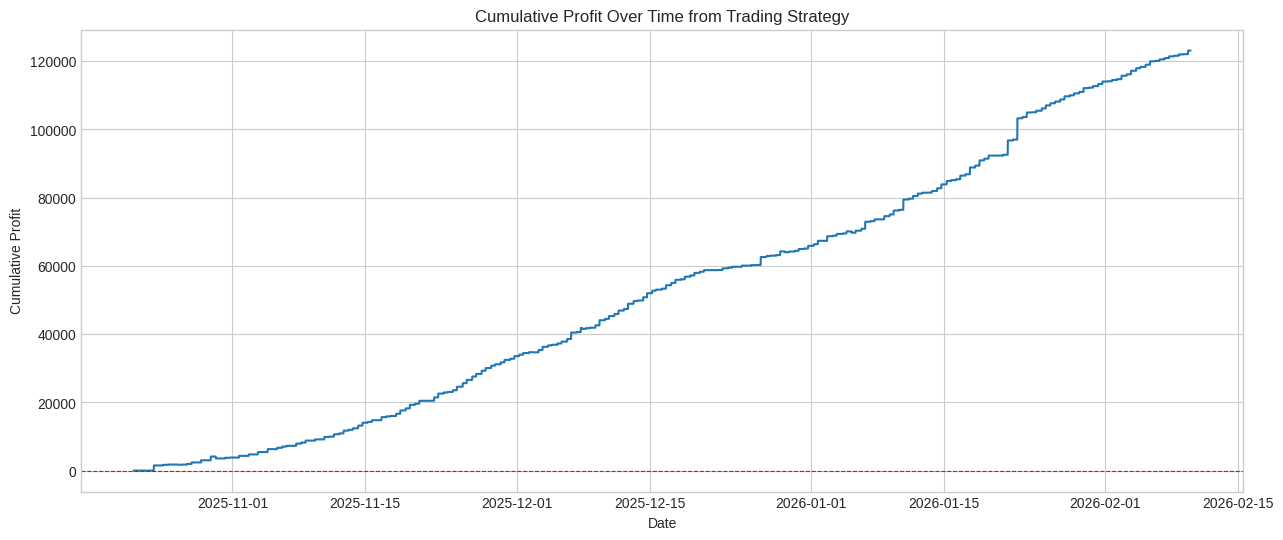

In [ ]:
import matplotlib.pyplot as plt

# Calculated the financial outcome (total profit/loss)
total_profit = trade_df['trade_profit'].sum()
print(f"Total simulated profit/loss: {total_profit:.2f}")

# Calculated cumulative profit for visualization
trade_df['cumulative_profit'] = trade_df['trade_profit'].cumsum()

# Ploted the cumulative profit over time
plt.figure(figsize=(15, 6))
sns.lineplot(x='datetime', y='cumulative_profit', data=trade_df)
plt.title('Cumulative Profit Over Time from Trading Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative Profit')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Added a zero line for reference
plt.show()

The Cumulative Profit graph demonstrates a consistently positive and upward-sloping trajectory, indicating that the trading strategy successfully captures market gains over the four-month period from November 2025 to February 2026.

The steady rise, with sharp vertical jumps, suggests that the model is particularly effective at capitalizing on high-volatility events, resulting in a total cumulative profit exceeding 120,000.

**Conclusion**

By integrating technical performance with market behavior, we successfully developed an LGBM based forecasting framework that achieved a MAPE of 0.3081, outperforming Random Forest and XGBoost in handling the market's extreme volatility.

The analysis revealed that while bid surplus and seasonal cycles are the primary drivers, the model's true strength lies in navigating the non-linear relationship between weather anomalies (temperature/wind) and the recurring 10,000 Rs/MWh price ceiling.

This predictive accuracy was translated into a robust trading strategy that favored a bullish bias (61% Buy signals) to capture peaks most notably the 7 PM daily surge resulting in a consistent cumulative profit exceeding 120,000.

Ultimately, the strategy’s success is rooted in its ability to balance long-term seasonal trends with immediate 24-hour price momentum, turning high-variance energy shifts into a steady upward financial trajectory.